# C15 · Should Parkay run a promotion?

| | |
|---|---|
| **Difficulty** | ★★★★☆ |
| **Time** | 4-5 hours |
| **Data** | The margarine scanner panel of Allenby & Rossi (1991; A.C. Nielsen, distributed with the R package bayesm): 4,470 purchases by 516 households among 10 products, each purchase with the shelf price of every product on that shopping trip |
| **Skills** | Multinomial logit for choice · price-coefficient sanity checks and elasticities · IIA and what it does to cannibalisation · hierarchical (random-coefficient) logit with correlated household tastes and a lognormal price sensitivity · centred vs non-centred hierarchies with ~500 groups · held-out scoring of a panel model · state dependence vs heterogeneity · counterfactual simulation with carry-over · posterior of incremental profit and a go/no-go decision |

## The brief

You work for the brand manager of **Parkay** margarine. Parkay sells sticks (its big seller) and
tubs. The retailer has offered a slot for a **temporary price reduction of 20% on Parkay sticks**,
funded entirely by Parkay. The brand manager asks:

> "If we cut the stick price by 20% for a promotion period, how much extra share do Parkay sticks
> get? How much of that comes out of our own tubs, and how much do we steal from Blue Bonnet, the
> house brand and the rest? And after all that - **does it make money?** My team says promotions
> also win us loyal customers who keep buying Parkay afterwards, so count that too. I want to be
> at least **80% sure** a promotion pays before I sign."

The economics, as the brand manager gives them (treat them as fixed):

* **Regular prices** are each product's median shelf price in the panel (computed below).
  The promotion cuts the Parkay stick price by 20% for one shopping trip of every household
  (the promotion period); all other products stay at their regular prices.
* Parkay's **contribution margin** at regular prices is **\$0.25 per lb on sticks** and **\$0.45
  per lb on tubs**. Parkay funds the cut, so every promoted pound of sticks earns 20% of the
  regular shelf price less.
* The region sells about **200,000 lb of margarine** (all brands) in a promotion period. Treat
  every purchase as one pound (the panel has no quantities).
* **Carry-over** counts: purchases on each household's **next 6 shopping trips**, at regular
  prices, that the promotion changed.

This is the pricing sequel to example **E84** (market structure from the same panel). Do E84
first: it introduces the data, the pooled logit and its IIA property, and the idea that apparent
loyalty can be heterogeneity in disguise. Here the question is a price decision, the model is a
full random-coefficient logit, and the output is a profit distribution.

## How this notebook works

- Each task states **what to deliver**, not how. Write your code in the `YOUR CODE HERE` cells.
- Stuck? `h.hint("task2")` reveals hints one level at a time: *nudge → approach → code skeleton*.
  Try to get by on nudges.
- `h.check("task2", price_sd=...)` compares your numbers with the reference solution.
- A full worked solution lives in `notebooks/solutions/`. Open it only when you are done (or truly stuck).

In [1]:
import logging
import time

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
from scipy import special

from pymc_challenges import Hints, data

RANDOM_SEED = 1991
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)  # several fits: no sampler banner per fit

h = Hints("C15")
h.tasks()

**C15 - Should Parkay run a promotion?**

- `task0` - Look at Parkay's prices (3 hints, 2 check(s))
- `task1` - The pooled logit (3 hints, 2 check(s))
- `task2` - Households have their own tastes (3 hints, 3 check(s))
- `task3` - Loyalty (3 hints, 2 check(s))
- `task4` - Simulate the promotion (3 hints, 5 check(s))
- `task5` - Does it pay? (3 hints, 3 check(s))

## The data

One row per purchase, in time order within each household (the panel has no dates). `choice` is
the product bought; `price_<product>` is the shelf price in US\$ per lb of **every** product on
that trip, bought or not. Products: `Pk` = Parkay, `BB` = Blue Bonnet, `Fl` = Fleischmann's,
`Hse` = the store's house brand, `Gen` = generic, `Imp` = Imperial, `SS` = Shedd's Spread;
`_Stk` = sticks, `_Tub` = tub.

The cell below adds integer codes (`y`, `hh`), each purchase's **previous** purchase by the same
household (`prev`), and the evaluation split used throughout: a household's first purchase is
only used as the "previous purchase" of its second (so that every model sees the same rows), and
the **last purchase of every household with at least three** is held out for scoring. The
regular prices of the brief are in `REG`.

In [2]:
data.describe("margarine")
df = data.load("margarine")
PRODUCTS = ["Pk_Stk", "BB_Stk", "Fl_Stk", "Hse_Stk", "Gen_Stk", "Imp_Stk",
            "SS_Tub", "Pk_Tub", "Fl_Tub", "Hse_Tub"]
J = len(PRODUCTS)
STK, TUB = PRODUCTS.index("Pk_Stk"), PRODUCTS.index("Pk_Tub")
PRICE_COLS = [f"price_{p}" for p in PRODUCTS]

df["y"] = df["choice"].map({p: j for j, p in enumerate(PRODUCTS)})
df["hh"] = pd.factorize(df["hhid"])[0]
H = df["hh"].max() + 1
df["prev"] = df.groupby("hh")["y"].shift(1)
df["T"] = df.groupby("hh")["trip"].transform("max")
rows = df[df["trip"] >= 2].copy()
rows["test"] = (rows["trip"] == rows["T"]) & (rows["T"] >= 3)
train, test = rows[~rows["test"]], rows[rows["test"]]

REG = df[PRICE_COLS].median().to_numpy()          # regular shelf prices (US$ per lb)
DEPTH = 0.20                                      # the promotion: 20% off Parkay sticks
MARGIN_STK, MARGIN_TUB = 0.25, 0.45               # Parkay's margin per lb at regular prices
VOLUME = 200_000                                  # category purchases (lb) in the promotion period
CARRY_TRIPS = 6                                   # later trips that count as carry-over

print(f"{len(df):,} purchases by {H} households; {len(train):,} training rows, "
      f"{len(test)} held-out last purchases")
print("regular prices:", dict(zip(PRODUCTS, REG.round(2))))
df.head()

margarine: 4,470 margarine purchases by 516 households, in time order within household (no dates): hhid, trip (1, 2, ... within household), choice (one of 10 products: Pk = Parkay, BB = Blue Bonnet, Fl = Fleischmann's, Hse = the store's house brand, Gen = generic, Imp = Imperial, SS = Shedd's Spread; _Stk = sticks, _Tub = tub), and price_<product>: the shelf price (US$ per pound) of every product on that shopping trip.
  source: Allenby & Rossi (1991), 'Quality perceptions and asymmetric switching between brands', Marketing Science 10:185-205: an A.C. Nielsen scanner panel, distributed as `margarine` in the R package bayesm (Rossi; GPL >= 2; the URL is its CRAN source tarball). CONVERTED from .rda by tools/build_e84_margarine.py - keep the cached file.
  url:    https://cran.r-project.org/src/contrib/Archive/bayesm/bayesm_3.1-6.tar.gz
4,470 purchases by 516 households; 3,498 training rows, 456 held-out last purchases
regular prices: {'Pk_Stk': np.float64(0.58), 'BB_Stk': np.float64(0.5

,hhid,trip,choice,price_Pk_Stk,price_BB_Stk,price_Fl_Stk,price_Hse_Stk,price_Gen_Stk,price_Imp_Stk,price_SS_Tub,price_Pk_Tub,price_Fl_Tub,price_Hse_Tub,y,hh,prev,T
0,2100016,1,Pk_Stk,0.66,0.67,1.09,0.57,0.36,0.93,0.85,1.09,1.19,0.33,0,0,NaN,7
1,2100016,2,Pk_Stk,0.63,0.67,0.99,0.57,0.36,1.03,0.85,1.09,1.19,0.37,0,0,0.0,7
2,2100016,3,Pk_Stk,0.29,0.50,0.99,0.57,0.36,0.69,0.79,1.09,1.19,0.59,0,0,0.0,7
3,2100016,4,Pk_Stk,0.62,0.61,0.99,0.57,0.36,0.75,0.85,1.09,1.19,0.59,0,0,0.0,7
4,2100016,5,Pk_Stk,0.50,0.58,0.99,0.45,0.33,0.72,0.85,1.07,1.19,0.59,0,0,0.0,7


## Task 0 · Look at Parkay's prices

**Deliver**
1. The distribution of the Parkay stick price over trips. Is a 20% cut from the regular price
   something the data have seen, or an extrapolation? Where does most of the price variation
   come from?
2. The raw promotion response: Parkay stick share and Parkay tub share on trips grouped by the
   Parkay stick price, with uncertainty. What does it suggest about cannibalisation?
3. One reason this raw comparison is not the answer to the brief.

In [3]:
BLUE, ORANGE, AQUA, GREY, PURPLE, RED = "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#8c5ac8", "#c8384e"
pk = df["price_Pk_Stk"]
bins = [0, 0.32, 0.47, 0.55, 1.0]
labels = ["deep deal\n<= $0.32", "$0.33-0.47", "$0.48-0.55", "regular\n>= $0.56"]
df["pk_band"] = pd.cut(pk, bins, labels=labels)
band = df.groupby("pk_band", observed=True).agg(
    n=("y", "size"), stk=("y", lambda s: (s == STK).mean()), tub=("y", lambda s: (s == TUB).mean()))
band

,n,stk,tub
pk_band,,,
deep deal\n<= $0.32,921,0.770901,0.013029
$0.33-0.47,183,0.409836,0.065574
$0.48-0.55,351,0.549858,0.045584
regular\n>= $0.56,3015,0.261360,0.054063


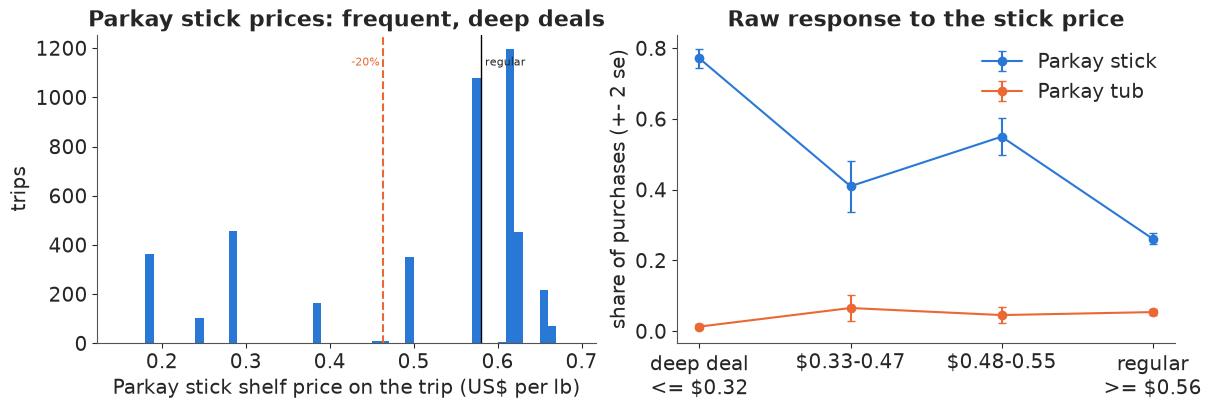

In [4]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.hist(pk, bins=np.arange(0.15, 0.70, 0.01), color=BLUE)
a1.axvline(REG[STK], color="k", lw=1)
a1.axvline((1 - DEPTH) * REG[STK], color=ORANGE, lw=1.5, ls="--")
a1.text(REG[STK] + 0.005, a1.get_ylim()[1] * 0.9, "regular", fontsize=8)
a1.text((1 - DEPTH) * REG[STK] - 0.005, a1.get_ylim()[1] * 0.9, "-20%", fontsize=8, ha="right",
        color=ORANGE)
a1.set(xlabel="Parkay stick shelf price on the trip (US$ per lb)", ylabel="trips",
       title="Parkay stick prices: frequent, deep deals")
x = np.arange(len(band))
for col, colr, lab in [("stk", BLUE, "Parkay stick"), ("tub", ORANGE, "Parkay tub")]:
    p, n = band[col].to_numpy(), band["n"].to_numpy()
    se = np.sqrt(p * (1 - p) / n)
    a2.errorbar(x, p, yerr=2 * se, fmt="o-", color=colr, label=lab, capsize=3)
a2.set_xticks(x, band.index)
a2.set(ylabel="share of purchases (+- 2 se)", title="Raw response to the stick price")
a2.legend();

In [5]:
share_promo = (df.loc[pk <= 0.47, "y"] == STK).mean()
share_regular = (df.loc[pk >= 0.55, "y"] == STK).mean()
print(f"Parkay stick share: {share_promo:.3f} at <= $0.47, {share_regular:.3f} at >= $0.55; "
      f"trips with a price within 3 cents of the promotion price: "
      f"{(abs(pk - (1 - DEPTH) * REG[STK]) <= 0.03).sum()}")
assert h.check("task0", share_promo=share_promo, share_regular=share_regular)

Parkay stick share: 0.711 at <= $0.47, 0.261 at >= $0.55; trips with a price within 3 cents of the promotion price: 17


- PASS `share_promo` = 0.7111 is consistent with the reference solution.
- PASS `share_regular` = 0.2614 is consistent with the reference solution.

### Solution

The regular Parkay stick price is about \$0.58-0.63 (median \$0.58); the promotion would charge
\$0.46. That exact price is rare (17 trips within 3 cents of it), but there are 351 trips at
\$0.48-0.55 (mostly \$0.50) and 183 at \$0.33-0.47, so a 20% cut lies **inside the range of the
data**, between observed price points. Most of the price variation, though, comes from very deep
deals at \$0.19-0.29 - half price or less - on about a fifth of the trips (921). A model with
utility linear in price will learn its price coefficient largely from those and then be asked
about a much shallower cut.

The raw response is enormous: Parkay sticks take 77% of purchases on deep-deal trips against 26%
at regular prices. The tub share is lowest on deep-deal trips (1% against 5%), a first hint of
cannibalisation - but tubs are a small product, so most of the stick gain must come from rivals.

Why this is not the answer: (i) deal trips are not random - other brands' prices differ on those
trips (note that the \$0.33-0.47 band shows a *lower* stick share than the \$0.48-0.55 band, which
no sensible price response explains on its own), and the deep deals were probably advertised
(feature ads and displays are not in the data); (ii) the households shopping on deal trips may be
different households; (iii) the comparison says nothing about where the extra buyers came from or
what they do afterwards. A choice model holds the other prices fixed and separates households.

## Task 1 · The pooled logit, and what it says about the promotion

Fit a multinomial logit in which every household shares the same product intercepts and the
same price coefficient (no previous-purchase term yet).

**Deliver**
1. The price coefficient, with a sanity check: its sign, and the own-price **elasticity** of
   Parkay sticks it implies at regular prices. Is that plausible for a grocery brand?
2. The promotion at regular prices: Parkay stick share before and after the 20% cut, the gain in
   percentage points, and **where the gain comes from** - for each other product, its share of the
   gain, compared with its share of the non-Parkay-stick market. Explain the pattern you find.

In [6]:
X_tr = train[PRICE_COLS].to_numpy()
X_te = test[PRICE_COLS].to_numpy()
y_tr, y_te = train["y"].to_numpy(), test["y"].to_numpy()
hh_tr, hh_te = train["hh"].to_numpy(), test["hh"].to_numpy()
last_tr = np.eye(J)[train["prev"].astype(int).to_numpy()]
last_te = np.eye(J)[test["prev"].astype(int).to_numpy()]
coords = {"product": PRODUCTS, "alt": PRODUCTS[1:], "hh": np.arange(H),
          "coef": [f"alpha_{p}" for p in PRODUCTS[1:]] + ["log_price_sens"]}


def pooled_logit(lag=False):
    """Same intercepts and price coefficient for everybody; Parkay sticks are the reference."""
    with pm.Model(coords=coords) as m:
        a = pm.Normal("alpha", 0, 2, dims="alt")
        alpha = pt.concatenate([pt.zeros(1), a])
        beta = pm.Normal("beta", -3, 3)
        V = alpha + beta * X_tr
        if lag:
            V = V + pm.Normal("gamma", 0, 2) * last_tr
        pm.Categorical("y", logit_p=V, observed=y_tr)
    return m


def fit(model, **kw):
    t0 = time.time()
    with model:
        idata = pm.sample(random_seed=RANDOM_SEED, **kw)
    ss = idata.sample_stats
    print(f"sampled in {time.time() - t0:.0f} s (nutpie, {idata.posterior.attrs.get('tuning_steps')}"
          f" warm-up steps); divergences {int(ss['diverging'].sum())}, "
          f"max tree depth {int(ss['depth'].max())}")
    return idata


idata_pool = fit(pooled_logit())
az.summary(idata_pool, var_names=["beta", "alpha"], round_to=2)

sampled in 5 s (nutpie, 400 warm-up steps); divergences 0, max tree depth 4


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
beta,-6.41,0.21,-6.72,-6.07,893.71,1412.43,1.0,0.01,0.0
alpha[BB_Stk],-0.96,0.06,-1.05,-0.87,4682.24,3095.76,1.0,0.00,0.0
alpha[Fl_Stk],1.13,0.13,0.93,1.33,1158.56,1616.68,1.0,0.00,0.0
alpha[Hse_Stk],-1.63,0.06,-1.73,-1.54,3147.80,3305.10,1.0,0.00,0.0
alpha[Gen_Stk],-2.81,0.08,-2.93,-2.68,2291.50,2709.63,1.0,0.00,0.0
alpha[Imp_Stk],-1.55,0.14,-1.77,-1.34,3486.97,2756.90,1.0,0.00,0.0
alpha[SS_Tub],0.07,0.09,-0.08,0.21,1714.30,2193.94,1.0,0.00,0.0
alpha[Pk_Tub],1.36,0.14,1.14,1.58,1089.49,1566.56,1.0,0.00,0.0
alpha[Fl_Tub],2.19,0.16,1.93,2.43,1032.00,1390.22,1.0,0.00,0.0
alpha[Hse_Tub],-3.89,0.20,-4.22,-3.58,6305.62,3361.10,1.0,0.00,0.0


### Solution

Parkay sticks are the reference product (intercept 0), because adding a constant to every
utility changes nothing. The price prior Normal(-3, 3) per dollar allows anything from no price
response to an extreme one, and does not force the sign.

To turn any fitted model into predictions we need, per posterior draw, every household's
intercepts $A_{hj}$, price coefficient $b_h$ and state-dependence coefficient $\gamma$. For the
pooled model all households are the same. The helper below returns them in one format for all the
models of this notebook (it already knows about the hierarchical model of Task 2).

In [7]:
def household_params(idata, S=400):
    """A (S, H, J) household intercepts, b (S, H) price coefficients, g (S,) state dependence."""
    p = az.extract(idata, num_samples=S, random_seed=RANDOM_SEED)
    if "theta" in p:
        th = p["theta"].transpose("sample", "hh", "coef").to_numpy()
        A = np.concatenate([np.zeros((S, H, 1)), th[..., :-1]], axis=-1)
        b = -np.exp(th[..., -1])
    else:
        a = p["alpha"].transpose("sample", "alt").to_numpy()
        A = np.repeat(np.concatenate([np.zeros((S, 1)), a], axis=1)[:, None], H, axis=1)
        b = np.repeat(p["beta"].to_numpy()[:, None], H, axis=1)
    g = p["gamma"].to_numpy() if "gamma" in p else np.zeros(S)
    return A, b, g


def promo_trip(A, b, g, state, depth=DEPTH):
    """Choice probabilities (S, H, J) on one trip at regular prices and with the stick cut."""
    X1 = REG.copy()
    X1[STK] *= 1 - depth
    V0 = A + b[..., None] * REG + g[:, None, None] * state
    V1 = A + b[..., None] * X1 + g[:, None, None] * state
    return special.softmax(V0, -1), special.softmax(V1, -1)


no_state = np.zeros((H, J))                  # Task 1: no previous-purchase effect
P0, P1 = promo_trip(*household_params(idata_pool), no_state)
s0, s1 = P0.mean(1), P1.mean(1)              # population shares per draw
gain = s1[:, STK] - s0[:, STK]
beta_draws = az.extract(idata_pool, var_names="beta").to_numpy()
elast = -np.median(beta_draws) * REG[STK] * (1 - s0[:, STK])
print(f"beta: {np.median(beta_draws):.2f} per $/lb; Parkay stick share at regular prices "
      f"{np.median(s0[:, STK]):.3f} -> {np.median(s1[:, STK]):.3f} with the cut "
      f"(+{100 * np.median(gain):.1f} points); own-price elasticity {np.median(elast):.1f}")


def gain_sources(s0, s1):
    """Each other product's share of the stick gain, and that share relative to its market share."""
    loss = -(s1 - s0)[:, 1:] / (s1 - s0)[:, [STK]]
    iia = s0[:, 1:] / (1 - s0[:, [STK]])
    return loss, iia


loss, iia = gain_sources(s0, s1)
pd.DataFrame({"share of the gain": np.median(loss, 0), "share of rest of market": np.median(iia, 0),
              "ratio": np.median(loss / iia, 0)}, index=PRODUCTS[1:]).round(3)

beta: -6.41 per $/lb; Parkay stick share at regular prices 0.337 -> 0.517 with the cut (+18.0 points); own-price elasticity 2.5


,share of the gain,share of rest of market,ratio
BB_Stk,0.194,0.194,1.0
Fl_Stk,0.115,0.115,1.0
Hse_Stk,0.229,0.229,1.0
Gen_Stk,0.151,0.151,1.0
Imp_Stk,0.036,0.036,1.0
SS_Tub,0.097,0.097,1.0
Pk_Tub,0.076,0.076,1.0
Fl_Tub,0.091,0.091,1.0
Hse_Tub,0.010,0.010,1.0


In [8]:
assert h.check("task1", beta=np.median(beta_draws), gain_pp=100 * np.median(gain))

- PASS `beta` = -6.412 is consistent with the reference solution.
- PASS `gain_pp` = 17.99 is consistent with the reference solution.

**Sanity.** The coefficient is negative (higher price, lower utility) and large: about -6.4 per
dollar per pound, so a 10-cent cut multiplies a product's odds by about $e^{0.64} \approx 1.9$.
At regular prices that is an own-price elasticity of about **-2.5** for Parkay sticks, right at
the average that meta-analyses report for grocery brands (Bijmolt, van Heerde & Pieters 2005).
Plausible - but keep in mind that it is learned mostly from the deep deals of Task 0, which were
probably advertised, and that the pooled model averages very different households (Task 2).

**The promotion.** The pooled logit says the cut lifts Parkay sticks by about 18 points (from 0.34
to 0.52 of purchases at regular prices). And the source of every point is **exactly
proportional to the other products' shares**: the ratio column is 1.0 for every product. Parkay
tubs give up 7.6% of the gain because they hold 7.6% of the rest of the market - no more, no less. This
is IIA (independence of irrelevant alternatives): in a logit the odds between any two products
do not depend on a third, so a product gaining share takes it from everybody in proportion. The
model cannot say that Parkay tub buyers are closer to Parkay sticks than Fleischmann's buyers are:
it assumed the cannibalisation answer before seeing any data.

## Task 2 · Households have their own tastes

Give every household its own product intercepts **and** its own price sensitivity, drawn from a
population distribution that lets them be **correlated** (do households who like the premium
brands care less about price?). Keep the price coefficient negative for everybody.

**Deliver**
1. The model written in its most direct form first. Diagnose what is wrong with the sampling,
   then fix it. Report what you changed and the diagnostics before and after.
2. The population median price coefficient and the household-to-household spread of price
   sensitivity. Which products' fans are least price-sensitive?
3. A comparison with the pooled logit on the **held-out last purchases**: the gain in
   log predictive density, with a standard error.

In [9]:
def hier_logit(lag=False, centred=False, X=X_tr, last=last_tr, hh=hh_tr, y=y_tr):
    """Random-coefficient logit: 9 intercepts + log price sensitivity per household, correlated."""
    with pm.Model(coords=coords) as m:
        a = pm.Normal("alpha", 0, 2, dims="alt")              # population mean intercepts
        mu_b = pm.Normal("mu_b", 1.5, 1.0)                    # mean log price sensitivity
        chol, _, _ = pm.LKJCholeskyCov("chol", n=J, eta=2.0, sd_dist=pm.HalfNormal.dist(2.0),
                                       compute_corr=True)
        mu = pt.concatenate([a, mu_b[None]])
        if centred:
            theta = pm.MvNormal("theta", mu, chol=chol, dims=("hh", "coef"))
        else:
            z = pm.Normal("z", 0, 1, dims=("hh", "coef"))
            theta = pm.Deterministic("theta", mu + z @ chol.T, dims=("hh", "coef"))
        A = pt.concatenate([pt.zeros((H, 1)), theta[:, :-1]], axis=1)
        b = -pt.exp(theta[:, -1])                             # negative for every household
        V = A[hh] + b[hh, None] * X
        if lag:
            V = V + pm.Normal("gamma", 0, 2) * last
        pm.Categorical("y", logit_p=V, observed=y)
    return m


SCALARS = ["mu_b", "chol_stds"]
idata_centred = fit(hier_logit(centred=True), var_names=["alpha", "mu_b", "chol_stds"])
summ_c = az.summary(idata_centred, var_names=SCALARS, round_to=3)
print(f"centred: r_hat max {summ_c['r_hat'].max():.3f}, bulk ESS min {summ_c['ess_bulk'].min():.0f}")
summ_c

sampled in 92 s (nutpie, 400 warm-up steps); divergences 0, max tree depth 8
centred: r_hat max 1.083, bulk ESS min 33


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_b,2.211,0.045,2.137,2.281,245.799,476.538,1.019,0.003,0.001
chol_stds[0],1.485,0.132,1.276,1.703,505.494,883.169,1.013,0.006,0.003
chol_stds[1],4.211,0.494,3.425,5.011,198.486,368.562,1.008,0.035,0.017
chol_stds[2],2.258,0.177,1.986,2.549,309.842,557.852,1.007,0.010,0.004
chol_stds[3],2.744,0.243,2.373,3.143,266.198,502.268,1.021,0.015,0.006
chol_stds[4],2.796,0.418,2.150,3.482,32.835,91.693,1.083,0.074,0.021
chol_stds[5],3.582,0.358,3.027,4.167,228.696,382.987,1.013,0.024,0.010
chol_stds[6],3.134,0.457,2.454,3.918,67.770,195.567,1.064,0.055,0.018
chol_stds[7],4.052,0.559,3.220,5.022,129.077,155.614,1.042,0.050,0.028
chol_stds[8],3.592,0.487,2.850,4.389,118.153,198.261,1.018,0.045,0.024


### Solution

The direct ("centred") form draws every household's coefficient vector from
$\text{MvNormal}(\mu, \Sigma)$ with an LKJ prior on the correlations and HalfNormal(2) priors on
the ten standard deviations. It samples without divergences, but look at the table: r_hat up to
about 1.08, several sds with a bulk ESS below 150 (one about 30) out of 4000 draws, and trees of
depth 8 where the fix below needs 5 - it is also about four times slower. This is the funnel of a
hierarchical model: with only about eight purchases per household, each household's
coefficients are weakly identified, so their spread and the spreads $\Sigma$ move together and the
sampler crawls along that ridge.

The fix is the **non-centred** form: draw standard normals $z_h$ and set
$\theta_h = \mu + L z_h$ with $L$ the Cholesky factor. Same model, different geometry.

In [10]:
del idata_centred
idata_hier = fit(hier_logit(), var_names=["alpha", "mu_b", "chol_stds", "chol_corr", "theta"])
summ_h = az.summary(idata_hier, var_names=SCALARS, round_to=3)
print(f"non-centred: r_hat max {summ_h['r_hat'].max():.3f}, bulk ESS min {summ_h['ess_bulk'].min():.0f}")
summ_h

sampled in 21 s (nutpie, 400 warm-up steps); divergences 0, max tree depth 5
non-centred: r_hat max 1.016, bulk ESS min 216


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_b,2.213,0.044,2.141,2.282,697.304,972.356,1.011,0.002,0.001
chol_stds[0],1.491,0.134,1.283,1.717,1034.368,1587.769,1.002,0.004,0.002
chol_stds[1],4.206,0.504,3.407,5.010,317.158,676.704,1.016,0.028,0.013
chol_stds[2],2.248,0.177,1.978,2.543,562.384,1039.751,1.003,0.007,0.004
chol_stds[3],2.737,0.243,2.371,3.132,481.785,969.543,1.008,0.011,0.006
chol_stds[4],2.784,0.412,2.177,3.479,652.779,1011.453,1.011,0.016,0.009
chol_stds[5],3.615,0.377,3.050,4.268,534.656,785.042,1.007,0.016,0.009
chol_stds[6],3.167,0.463,2.466,3.941,444.969,719.339,1.004,0.022,0.012
chol_stds[7],4.064,0.518,3.285,4.912,458.011,729.252,1.007,0.024,0.013
chol_stds[8],3.535,0.491,2.801,4.363,752.574,1180.586,1.005,0.018,0.010


Now every r_hat is at most about 1.02, every bulk ESS is above 200 (most several times the
centred values), and sampling takes a quarter of the time. (The slowest quantity is the sd of
price sensitivity; for a final report you would run longer chains.) The sd of log price
sensitivity (the last entry) is about 0.4: households differ in price sensitivity by a factor of
$e^{2 \times 0.4} \approx 2.2$ between the 16th and 84th percentile - real but moderate
heterogeneity. The product intercepts vary far more (sds of 1.5-4.2 on the log-odds scale):
households differ much more in *what* they like than in how much they care about price.

median price coefficient -exp(mu_b): -9.16 per $/lb; sd of log price sensitivity 0.39


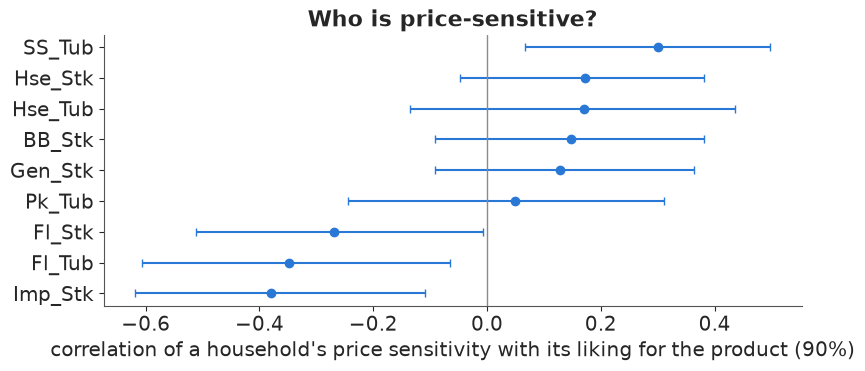

In [11]:
mu_b = az.extract(idata_hier, var_names="mu_b").to_numpy()
price_sd = az.extract(idata_hier, var_names="chol_stds").to_numpy()[-1]
corr = idata_hier.posterior["chol_corr"].to_numpy()[..., -1, :-1].reshape(-1, J - 1)
order = np.argsort(np.median(corr, 0))
fig, ax = plt.subplots(figsize=(8, 3.6))
lo, mid, hi = np.quantile(corr[:, order], [0.05, 0.5, 0.95], axis=0)
ax.errorbar(mid, np.arange(J - 1), xerr=[mid - lo, hi - mid], fmt="o", color=BLUE, capsize=3)
ax.axvline(0, color=GREY, lw=1)
ax.set_yticks(np.arange(J - 1), [PRODUCTS[1:][i] for i in order])
ax.set(xlabel="correlation of a household's price sensitivity with its liking for the product (90%)",
       title="Who is price-sensitive?");
print(f"median price coefficient -exp(mu_b): {-np.exp(np.median(mu_b)):.2f} per $/lb; "
      f"sd of log price sensitivity {np.median(price_sd):.2f}")

In [12]:
def heldout_pointwise(idata):
    """log p(held-out purchase | training data), one value per held-out purchase."""
    A, b, g = household_params(idata, S=1000)
    V = A[:, hh_te] + b[:, hh_te, None] * X_te + g[:, None, None] * last_te
    lp = (V - special.logsumexp(V, -1, keepdims=True))[:, np.arange(len(y_te)), y_te]
    return special.logsumexp(lp, 0) - np.log(len(lp))


def compare(pw, base):
    rows = {k: (v.sum(), (v - pw[base]).sum(), np.sqrt(len(v)) * (v - pw[base]).std())
            for k, v in pw.items()}
    return pd.DataFrame(rows, index=["elpd", f"diff vs {base}", "se of diff"]).T.round(1)


pw = {"pooled": heldout_pointwise(idata_pool), "hierarchical": heldout_pointwise(idata_hier)}
compare(pw, "pooled")

,elpd,diff vs pooled,se of diff
pooled,-645.0,0.0,0.0
hierarchical,-384.9,260.1,23.4


In [13]:
elpd_gain = (pw["hierarchical"] - pw["pooled"]).sum()
assert h.check("task2", median_beta=-np.exp(np.median(mu_b)), price_sd=np.median(price_sd),
               elpd_gain=elpd_gain)

- PASS `median_beta` = -9.159 is consistent with the reference solution.
- PASS `price_sd` = 0.3917 is consistent with the reference solution.
- PASS `elpd_gain` = 260.1 is consistent with the reference solution.

The median household's price coefficient is about **-9 per dollar**, steeper than the pooled -6.4:
the pooled model mixes households that never switch whatever the price (whose purchases look
price-insensitive) with households that do, and averages their responses into a flatter curve.

Fans of the **premium** products - Fleischmann's (stick and tub) and Imperial - are the least
price-sensitive (correlations of about -0.3 to -0.4, 90% intervals below zero). Fans of Shedd's
Spread are the most price-sensitive (+0.3); the value products and Blue Bonnet lean the same way,
with intervals that include zero. Parkay tub fans are average.

On the held-out purchases the hierarchical model is better by about **260 nats** on 456 purchases,
eleven standard errors: knowing the household matters far more than anything else in this notebook.

## Task 3 · Loyalty: does buying Parkay make you buy Parkay?

The brand manager's team believes promotions "win loyal customers". In a choice model that is
**state dependence**: buying a product last time raises the chance of buying it again, beyond a
household's fixed tastes.

**Deliver**
1. Add the previous purchase to the pooled and to the hierarchical model. How big is the
   loyalty effect in each, as an odds ratio, and why do they disagree?
2. What adding it does to the estimated **heterogeneity** (the sds of Task 2), and what the
   held-out purchases say about the four models.
3. Which loyalty estimate should go into the promotion's carry-over, and why.

In [14]:
idata_pool_lag = fit(pooled_logit(lag=True))
idata_hier_lag = fit(hier_logit(lag=True),
                     var_names=["alpha", "mu_b", "chol_stds", "gamma", "theta"])
summ_hl = az.summary(idata_hier_lag, var_names=SCALARS + ["gamma"], round_to=3)
print(f"hierarchical + lag: r_hat max {summ_hl['r_hat'].max():.3f}, "
      f"bulk ESS min {summ_hl['ess_bulk'].min():.0f}")
gamma_pooled = np.median(az.extract(idata_pool_lag, var_names="gamma").to_numpy())
gamma_hier = np.median(az.extract(idata_hier_lag, var_names="gamma").to_numpy())
print(f"gamma pooled {gamma_pooled:.2f} (odds x{np.exp(gamma_pooled):.1f}); "
      f"hierarchical {gamma_hier:.2f} (odds x{np.exp(gamma_hier):.2f})")

sampled in 3 s (nutpie, 400 warm-up steps); divergences 0, max tree depth 5


sampled in 22 s (nutpie, 400 warm-up steps); divergences 0, max tree depth 5
hierarchical + lag: r_hat max 1.016, bulk ESS min 302
gamma pooled 1.79 (odds x6.0); hierarchical 0.36 (odds x1.44)


In [15]:
sds = pd.DataFrame({
    "no lag": az.extract(idata_hier, var_names="chol_stds").to_numpy().mean(1),
    "with lag": az.extract(idata_hier_lag, var_names="chol_stds").to_numpy().mean(1)},
    index=coords["coef"])
sds["ratio"] = sds["no lag"] / sds["with lag"]
pw |= {"pooled + lag": heldout_pointwise(idata_pool_lag),
       "hierarchical + lag": heldout_pointwise(idata_hier_lag)}
display(sds.round(2))
compare(pw, "hierarchical + lag")

,no lag,with lag,ratio
alpha_BB_Stk,1.49,1.25,1.19
alpha_Fl_Stk,4.21,3.81,1.10
alpha_Hse_Stk,2.25,2.01,1.12
alpha_Gen_Stk,2.74,2.48,1.10
alpha_Imp_Stk,2.78,2.59,1.08
alpha_SS_Tub,3.62,3.23,1.12
alpha_Pk_Tub,3.17,2.92,1.08
alpha_Fl_Tub,4.06,3.74,1.09
alpha_Hse_Tub,3.54,3.31,1.07
log_price_sens,0.39,0.39,1.02


,elpd,diff vs hierarchical + lag,se of diff
pooled,-645.0,-258.7,23.1
hierarchical,-384.9,1.4,2.4
pooled + lag,-561.3,-174.9,16.8
hierarchical + lag,-386.3,0.0,0.0


In [16]:
assert h.check("task3", gamma_pooled=gamma_pooled, gamma_hier=gamma_hier)

- PASS `gamma_pooled` = 1.792 is consistent with the reference solution.
- PASS `gamma_hier` = 0.3649 is consistent with the reference solution.

### Solution

The pooled logit says buying a product last time multiplies the odds of buying it again by about
**6**. With household tastes in the model, the effect falls to an odds ratio of about **1.4**.
Most of the pooled "loyalty" is **spurious state dependence** (Heckman 1981): a household that
bought Fleischmann's last time is a Fleischmann's household, and would have bought it anyway. The
pooled model has nowhere else to put that persistence, so it credits it to the last purchase.

The reverse also happens. Without the lag, the hierarchical model's intercept sds are about 7-19%
larger: a little genuine state dependence (runs of the same product) is read as stronger fixed
tastes. The price-sensitivity sd does not move.

On held-out purchases the two hierarchical models are within about one standard error of each
other (the lag model 1.4 $\pm$ 2.4 behind), and both beat the pooled models by more than 170 nats. The
pooled model with the lag is much better than without it - the lag is a crude stand-in for
heterogeneity - but nowhere near the hierarchical models.

For the carry-over the right estimate is the **hierarchical** one: carry-over is a statement about
what the *same* household does next time *because of* the promoted purchase, which is exactly the
causal part of the persistence that $\gamma$ isolates once tastes are modelled. The data cannot
rule out a small genuine effect (the posterior of $\gamma$ is clearly positive), so we keep the
lag model for the decision and check that dropping it does not change the answer.

## Task 4 · Simulate the promotion

Use the households' current state: each household's most recent purchase in the panel is its
"previous purchase" when the promotion trip comes.

**Deliver**, for the pooled-with-lag and the hierarchical-with-lag model:
1. The Parkay stick share gain on the promotion trip (percentage points) and the fraction of the
   gain that is **cannibalised from Parkay tub**, compared with what IIA would have said.
2. Which rivals lose the most, relative to their size, under the hierarchical model, and why.
   (Call a product's share of the gain divided by its IIA share its "lift".)
3. The **carry-over**: the extra Parkay (stick + tub) purchases per household on each of the next
   6 trips at regular prices. Plot the decay for both models.

In [17]:
state = np.eye(J)[df.groupby("hh")["y"].last().sort_index().to_numpy()]   # latest purchase


def simulate(idata, depth=DEPTH, trips=CARRY_TRIPS):
    """Promotion-trip shares and the extra purchases on later trips (all per draw)."""
    A, b, g = household_params(idata)
    P0, P1 = promo_trip(A, b, g, state, depth)
    # transition matrix at regular prices: Q[s, h, k, j] = P(j | previous purchase k)
    Q = special.softmax(A[:, :, None, :] + b[:, :, None, None] * REG
                        + g[:, None, None, None] * np.eye(J), axis=-1)
    q0, q1, carry = P0, P1, []
    for _ in range(trips):
        q0 = np.einsum("shk,shkj->shj", q0, Q)
        q1 = np.einsum("shk,shkj->shj", q1, Q)
        carry.append((q1 - q0).mean(1))
    return dict(s0=P0.mean(1), s1=P1.mean(1), carry=np.stack(carry, 1))     # carry: (S, trips, J)


sims = {"pooled + lag": simulate(idata_pool_lag), "hierarchical + lag": simulate(idata_hier_lag)}
tab = {}
for name, r in sims.items():
    loss, iia = gain_sources(r["s0"], r["s1"])
    k = PRODUCTS[1:].index("Pk_Tub")
    tab[name] = {"stick share, regular": np.median(r["s0"][:, STK]),
                 "gain (points)": 100 * np.median(r["s1"][:, STK] - r["s0"][:, STK]),
                 "cannibalised from tub": np.median(loss[:, k]),
                 "IIA would say": np.median(iia[:, k]),
                 "tub lift (5-95%)": f"{np.median(loss[:, k] / iia[:, k]):.2f} "
                                     f"({np.quantile(loss[:, k] / iia[:, k], 0.05):.2f}-"
                                     f"{np.quantile(loss[:, k] / iia[:, k], 0.95):.2f})",
                 "carry-over, 6 trips": np.median(r["carry"][:, :, [STK, TUB]].sum((1, 2)))}
pd.DataFrame(tab).T.round(3)

,"stick share, regular",gain (points),cannibalised from tub,IIA would say,tub lift (5-95%),"carry-over, 6 trips"
pooled + lag,0.363139,15.532356,0.077102,0.071599,1.08 (1.07-1.09),0.141144
hierarchical + lag,0.342901,18.372291,0.069306,0.076682,0.91 (0.78-1.06),0.01917


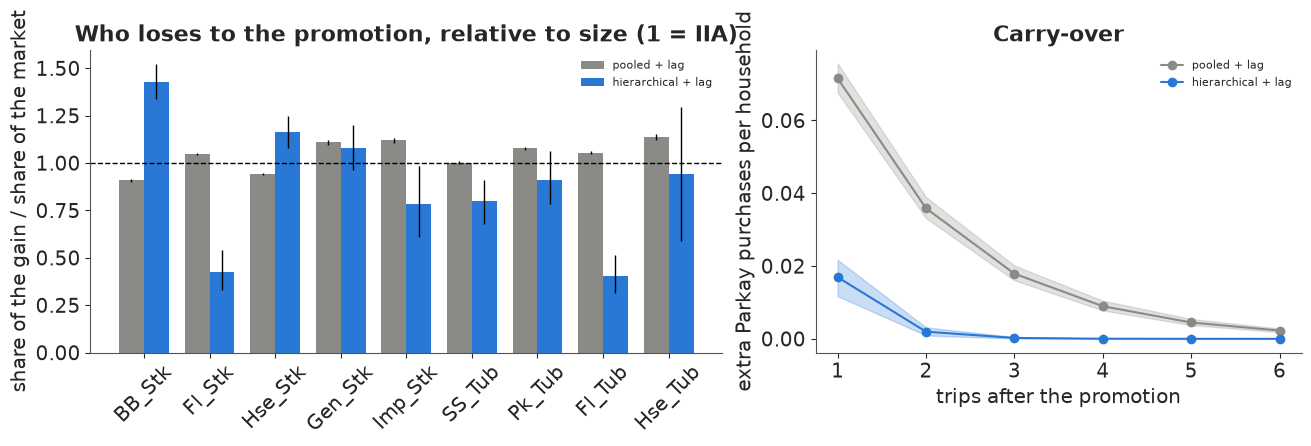

In [18]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.2), width_ratios=[1.3, 1])
w = 0.38
for i, (name, colr) in enumerate([("pooled + lag", GREY), ("hierarchical + lag", BLUE)]):
    loss, iia = gain_sources(sims[name]["s0"], sims[name]["s1"])
    lift = loss / iia
    lo, mid, hi = np.quantile(lift, [0.05, 0.5, 0.95], axis=0)
    xs = np.arange(J - 1) + (i - 0.5) * w
    a1.bar(xs, mid, w, color=colr, label=name)
    a1.errorbar(xs, mid, yerr=[mid - lo, hi - mid], fmt="none", color="k", lw=1)
a1.axhline(1, color="k", lw=1, ls="--")
a1.set_xticks(np.arange(J - 1), PRODUCTS[1:], rotation=45)
a1.set(ylabel="share of the gain / share of the market",
       title="Who loses to the promotion, relative to size (1 = IIA)")
a1.legend(fontsize=8)
for name, colr in [("pooled + lag", GREY), ("hierarchical + lag", BLUE)]:
    c = sims[name]["carry"][:, :, [STK, TUB]].sum(-1)
    lo, mid, hi = np.quantile(c, [0.05, 0.5, 0.95], axis=0)
    t = np.arange(1, CARRY_TRIPS + 1)
    a2.plot(t, mid, "o-", color=colr, label=name)
    a2.fill_between(t, lo, hi, color=colr, alpha=0.25)
a2.set(xlabel="trips after the promotion", ylabel="extra Parkay purchases per household",
       title="Carry-over")
a2.legend(fontsize=8);

In [19]:
r = sims["hierarchical + lag"]
loss, iia = gain_sources(r["s0"], r["s1"])
k = PRODUCTS[1:].index("Pk_Tub")
carry_pooled = np.median(sims["pooled + lag"]["carry"][:, :, [STK, TUB]].sum((1, 2)))
carry_hier = np.median(r["carry"][:, :, [STK, TUB]].sum((1, 2)))
assert h.check("task4", gain_pp=100 * np.median(r["s1"][:, STK] - r["s0"][:, STK]),
               cannibalised=np.median(loss[:, k]), bb_lift=np.median(loss[:, 0] / iia[:, 0]),
               carry_pooled=carry_pooled, carry_hier=carry_hier)

- PASS `gain_pp` = 18.37 is consistent with the reference solution.
- PASS `cannibalised` = 0.06931 is consistent with the reference solution.
- PASS `bb_lift` = 1.43 is consistent with the reference solution.
- PASS `carry_pooled` = 0.1411 is consistent with the reference solution.
- PASS `carry_hier` = 0.01917 is consistent with the reference solution.

### Solution

**The promotion trip.** The hierarchical model gives Parkay sticks a gain of about 18 points (from
0.34 to 0.53), the pooled-with-lag model about 15.5. They differ more in where it comes from. The
pooled model is no longer exactly IIA, because households now differ by their previous purchase,
but it has no idea who prefers what: all its lifts are within about 15% of 1. The hierarchical
model:

* takes about **7% of the gain from Parkay tub** - about what IIA says (lift 0.9, 90% interval
  0.78-1.06). So **cannibalisation is small**, and here IIA's answer happens to be about right; but
  the pooled model *assumed* it, while the hierarchical model *found* it, with an interval;
* takes **1.4 times its size from Blue Bonnet sticks**: the two mainstream sticks share their
  buyers (in E84's choice map both sit near the centre, drawing on the same mainstream
  households), so Blue Bonnet is Parkay's closest rival. The house-brand stick also loses a
  little more than its size;
* takes **less than half its size from Fleischmann's** (stick and tub): premium buyers are loyal to
  their brand and not very price-sensitive (Task 2), so a cheaper Parkay barely moves them.
  Imperial and Shedd's Spread also lose less than their size.

**Carry-over.** This is where the two models part ways. With the pooled model's odds-of-6
"loyalty", households that switched to Parkay on the promotion trip tend to stay, and the
promotion keeps paying for several trips: about 0.14 extra Parkay purchases per household
over the next six trips, almost as much again as the promotion trip itself. The hierarchical
model's carry-over is about 0.02 - a seventh of that, a tenth of the promotion-trip gain - and has
died out after two trips. The switchers on a promotion trip are mostly price-driven households,
who switch back when the price does.

## Task 5 · Does it pay?

**Deliver**
1. The posterior distribution of Parkay's **incremental profit** from the 20% promotion over the
   whole period (promotion trip plus carry-over, sticks and tubs, at the brief's margins and
   volume), and the probability that it pays. Show what the pooled-with-lag model would have told
   the brand manager.
2. The **break-even stick margin**: how large would Parkay's stick margin have to be for the 20%
   promotion to break even?
3. Is there a discount depth that the hierarchical model says pays? Plot expected incremental
   profit against depth (5% to 30%) with uncertainty, for both models.
4. A recommendation in plain words, including what this analysis cannot see.

pooled + lag           profit median $1,355 (90%: $758 to $2,043); P(pays) 1.000; break-even stick margin 0.228 (0.218-0.237)
hierarchical + lag     profit median $-3,299 (90%: $-3,924 to $-2,708); P(pays) 0.000; break-even stick margin 0.331 (0.313-0.351)
hierarchical (no lag)  profit median $-4,194 (90%: $-4,673 to $-3,702); P(pays) 0.000; break-even stick margin 0.367 (0.350-0.384)


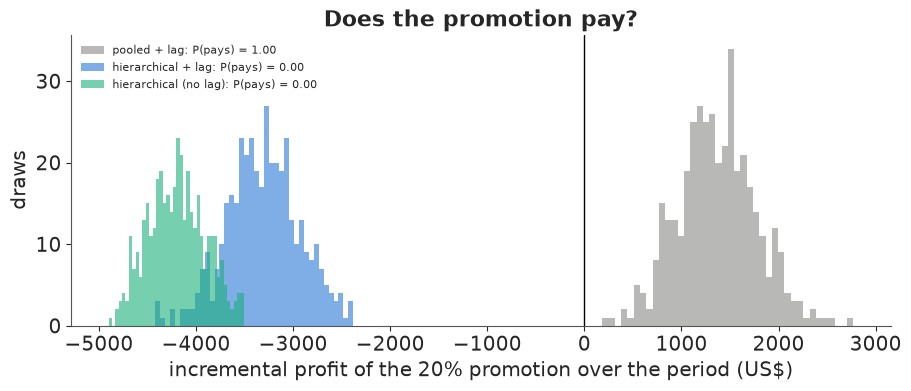

In [20]:
def profit(r, depth=DEPTH, m_stk=MARGIN_STK, m_tub=MARGIN_TUB):
    """Incremental profit in US$ over the period, per draw."""
    d_stk = r["s1"][:, STK] - r["s0"][:, STK] + r["carry"][:, :, STK].sum(1)
    d_tub = r["s1"][:, TUB] - r["s0"][:, TUB] + r["carry"][:, :, TUB].sum(1)
    promo_cost = depth * REG[STK] * r["s1"][:, STK]       # margin given away on promoted pounds
    return VOLUME * (m_stk * d_stk + m_tub * d_tub - promo_cost)


def breakeven_margin(r, depth=DEPTH, m_tub=MARGIN_TUB):
    d_stk = r["s1"][:, STK] - r["s0"][:, STK] + r["carry"][:, :, STK].sum(1)
    d_tub = r["s1"][:, TUB] - r["s0"][:, TUB] + r["carry"][:, :, TUB].sum(1)
    return (depth * REG[STK] * r["s1"][:, STK] - m_tub * d_tub) / d_stk


sims["hierarchical (no lag)"] = simulate(idata_hier)
fig, ax = plt.subplots(figsize=(9, 3.8))
for name, colr in [("pooled + lag", GREY), ("hierarchical + lag", BLUE),
                   ("hierarchical (no lag)", AQUA)]:
    pr = profit(sims[name])
    ax.hist(pr, bins=40, color=colr, alpha=0.6, label=f"{name}: P(pays) = {(pr > 0).mean():.2f}")
    print(f"{name:22s} profit median ${np.median(pr):,.0f} (90%: ${np.quantile(pr, 0.05):,.0f} to "
          f"${np.quantile(pr, 0.95):,.0f}); P(pays) {(pr > 0).mean():.3f}; break-even stick margin "
          f"{np.median(breakeven_margin(sims[name])):.3f} "
          f"({np.quantile(breakeven_margin(sims[name]), 0.05):.3f}-"
          f"{np.quantile(breakeven_margin(sims[name]), 0.95):.3f})")
ax.axvline(0, color="k", lw=1)
ax.set(xlabel="incremental profit of the 20% promotion over the period (US$)", ylabel="draws",
       title="Does the promotion pay?")
ax.legend(fontsize=8);

P(pays),5%,10%,15%,20%,25%,30%
pooled + lag,1.00,1.0,1.0,1.0,0.92,0.21
hierarchical + lag,0.22,0.0,0.0,0.0,0.00,0.00


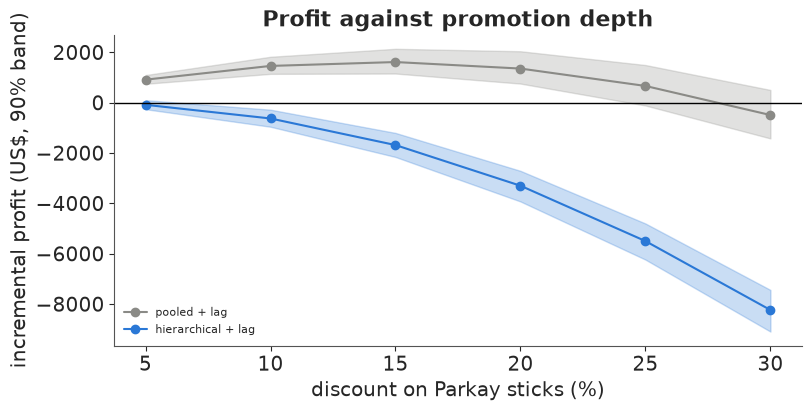

In [21]:
depths = np.array([0.05, 0.10, 0.15, 0.20, 0.25, 0.30])
fig, ax = plt.subplots(figsize=(8, 4))
curves = {}
for name, idata, colr in [("pooled + lag", idata_pool_lag, GREY),
                          ("hierarchical + lag", idata_hier_lag, BLUE)]:
    curves[name] = np.stack([profit(simulate(idata, depth=d), depth=d) for d in depths], 1)
    lo, mid, hi = np.quantile(curves[name], [0.05, 0.5, 0.95], axis=0)
    ax.plot(100 * depths, mid, "o-", color=colr, label=name)
    ax.fill_between(100 * depths, lo, hi, color=colr, alpha=0.25)
ax.axhline(0, color="k", lw=1)
ax.set(xlabel="discount on Parkay sticks (%)", ylabel="incremental profit (US$, 90% band)",
       title="Profit against promotion depth")
ax.legend(fontsize=8)
pd.DataFrame({name: (c > 0).mean(0) for name, c in curves.items()},
             index=[f"{int(100 * d)}%" for d in depths]).rename_axis("P(pays)").T.round(2)

In [22]:
pr = profit(sims["hierarchical + lag"])
assert h.check("task5", profit=np.median(pr), p_pays=(pr > 0).mean(),
               breakeven_margin=np.median(breakeven_margin(sims["hierarchical + lag"])))

- PASS `profit` = -3299 is consistent with the reference solution.
- PASS `p_pays` = 0 is consistent with the reference solution.
- PASS `breakeven_margin` = 0.331 is consistent with the reference solution.

### Solution

**The 20% promotion does not pay.** Under the hierarchical model with state dependence it loses
about \$3,300 over the period (90% interval roughly \$2,700 to \$3,900), and **no posterior draw
shows a profit**. Without the lag it loses about \$4,200 (no carry-over at all). The arithmetic
behind it: the cut gives away 11.6 cents on *every* promoted pound - including the third of the
market that buys Parkay sticks at the regular price anyway - and earns 25 cents on each extra
pound, while about 7% of the extra pounds come out of Parkay's own tubs at 45 cents. To break
even, Parkay's stick margin would have to be about **\$0.33 per lb** (90%: 0.31-0.35) instead of
\$0.25.

**What the pooled model would have said.** The same calculation with the pooled-with-lag model
says the promotion makes about \$1,400 and pays with certainty - an equally confident answer
with the opposite sign. Most of the difference is the carry-over: its spurious "loyalty" books
almost as many future Parkay purchases as the promotion trip itself. The brand manager's team was
making exactly the pooled model's mistake.

**Depth.** Under the hierarchical model the expected profit falls steadily with depth. At 5% it is
about break-even (a loss of roughly \$100, paying in about one draw in five); from 10% on, no
draw pays. The pooled-with-lag model would happily recommend anything from 5% to 25%.

**Recommendation.** Do not run the 20% promotion: at a \$0.25 stick margin the probability that it
pays is essentially zero, far from the 80% you asked for, and no deeper or shallower cut clears
that bar either. It would become worthwhile only if Parkay's effective stick margin were above
about \$0.33 per lb - for instance if the retailer co-funded the cut. The "loyal customers"
argument does not rescue it: once household tastes are modelled, the carry-over is about a tenth of
the promotion-trip gain.

**What this analysis cannot see.**
* **Category expansion and stockpiling.** The panel only records margarine purchases, so the model
  moves share between brands; it cannot see shoppers buying margarine *more often* (which would
  help) or buying several packs on deal and skipping later purchases (which would hurt - the
  classic post-promotion dip).
* **Advertised deals.** The price coefficient is learned mostly from deep deals that were probably
  supported by feature ads and displays (not in the data). If so, the response to a plain 20% cut
  is *overstated*, and the promotion is worse than shown here.
* **Retailer and competitor reactions** - pass-through below 100%, rival promotions - are outside
  the model.

Only category expansion could turn the answer around, and the size it would need is easy to
work out: a loss of about \$3,300 on 200,000 lb is 1.65 cents per category pound, and an extra
promoted stick pound earns 25 - 11.6 = 13.4 cents, so the promotion would have to bring in about
**12 extra pounds per 100 category purchases**, all of them Parkay sticks and none pulled forward
from later weeks. That is a lot to ask of a 20% cut on margarine, so the "no" stands - but it is a
"no" from a model of brand choice, not a measurement of category sales.

## Going further

- **Non-linear price response.** Utility linear in price learns its slope from the half-price
  deals and applies it to a 20% cut. Let the response bend (log price, a separate coefficient for
  the discount from the regular price, or a deal-depth spline) and see whether the shallow-cut
  profit changes.
- **Demographics in the hierarchy.** `margarine_demos` has income, family size and education for
  every household. Put them in the population mean of the household coefficients: are poorer or
  larger households more price-sensitive, and could Parkay target the promotion (a coupon) at them?
- **Reference prices.** Households who have seen Parkay at \$0.29 may treat \$0.46 as "not a deal".
  Add a reference-price (loss-aversion) term built from each household's past prices.
- **Who should be promoted?** Run the same calculation for a 20% cut on Parkay tubs or Blue
  Bonnet sticks. Which product's promotion steals most from rivals per dollar of margin given
  away?

In [23]:
h.progress()

**C15**: 0/18 hints used, 17/17 checks passed.